# 🧩 Andamiaje · Proyecto **Centinela** — Fase 1 (Línea base con MLP)
### Redes Neuronales — Deep Learning · Maestría en Ciencia de Datos · Universidad Santo Tomás

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/JotaMao1985/Deep_Learning_Usta/blob/main/notebooks/02-scaffold-centinela-fase1.ipynb)

Este cuaderno es un **andamiaje guía** (*scaffold*) para construir la **línea base tabular con MLP** de la Fase 1 del Proyecto Integrador *Centinela*. Trae lista la mecánica de soporte —carga de datos, exploración y funciones de graficado— y deja marcadas con `# TODO (estudiante)` las piezas que constituyen el trabajo evaluable: la **arquitectura del MLP**, el **bucle de entrenamiento** y el **experimento de sobreajuste**.

> **Cómo se usa:** se clona este cuaderno, se ejecutan las celdas de soporte en orden y se completan las celdas marcadas `# TODO (estudiante)`. En Google Colab: *Entorno de ejecución → Ejecutar todas* (las celdas TODO fallarán a propósito hasta que se completen).

> ⚠️ **Andamiaje — NO es la solución.** Este cuaderno **no** contiene un MLP entrenado ni un bucle de entrenamiento resuelto, y usa **datos sintéticos** (`make_moons` / `make_circles`), **no** los datos reales del proyecto. Su propósito es enseñar la *mecánica*; el diseño del modelo, el entrenamiento y el análisis los aporta el estudiante sobre **sus propios datos**.

---
**Contenido**
0. Preparación del entorno
1. Carga de datos sintéticos y partición *train / val / test*
2. Exploración mínima (EDA)
3. `# TODO (estudiante)` · Arquitectura del MLP (≥ 2 capas ocultas)
4. `# TODO (estudiante)` · Pérdida, optimizador y bucle de entrenamiento (50 épocas)
5. Funciones de diagnóstico provistas (curvas de pérdida y matriz de confusión)
6. `# TODO (estudiante)` · Inducir y corregir el sobreajuste con *Dropout*
7. Cierre · Lista de entregables


## 0. Preparación del entorno

Se importan las librerías de soporte (`numpy`, `scikit-learn`, `matplotlib`) y se fija una **semilla** para que los resultados sean reproducibles. La separación de miles se mostrará con punto, según la convención del material del curso.

> 💡 *PyTorch como TODO opcional:* las celdas de soporte de este andamiaje **no** requieren `torch`. La importación de PyTorch se deja como tarea del estudiante en la Sección 3, donde se define el modelo.


In [1]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Celda de soporte 1 · Preparación del entorno
# Qué hace · Importa las librerías de soporte, fija la semilla y configura el estilo de las gráficas.
# Por qué  · Una semilla fija hace comparables las ejecuciones: los cambios se deben a lo que ajustas, no al azar. La paleta solo unifica el estilo USTA.

# En Colab estas librerías ya vienen instaladas. Si faltara alguna, descomentar:
# !pip -q install scikit-learn matplotlib

%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, make_circles
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix

# Reproducibilidad: una misma semilla produce los mismos resultados en cada ejecución.
SEMILLA = 42
np.random.seed(SEMILLA)

# Paleta USTA para las gráficas
USTA_MORADO, USTA_ROSA, USTA_NAVY = "#3D008D", "#ED1E79", "#001A4D"
plt.rcParams.update({"figure.dpi": 110, "font.size": 11, "axes.grid": True, "grid.alpha": 0.3})

# Separador de miles con punto, según la convención del material del curso.
def miles(n):
    """Formatea un entero con punto como separador de miles (p. ej. 1.234.567)."""
    return f"{n:,}".replace(",", ".")

print("Entorno de soporte listo · numpy", np.__version__)

Entorno de soporte listo · numpy 2.4.4


## 1. Carga de datos sintéticos y partición *train / val / test*

Para practicar la mecánica **sin adelantar nada del proyecto**, se usa un conjunto **sintético** de clasificación binaria. Por defecto se generan **dos lunas** (`make_moons`): dos clases entrelazadas que ninguna recta separa, con la misma *forma* de dificultad que un problema real no lineal.

> 💡 *Para explorar:* basta cambiar `CONJUNTO = "lunas"` por `CONJUNTO = "circulos"` y volver a ejecutar desde aquí para trabajar con `make_circles`.

> 💡 **Puente con el proyecto:** en el proyecto real estas dos columnas serán **características tabulares** del problema elegido (intensidades de imagen, agregados de clima, etc.) y la etiqueta será el **evento de riesgo**. Aquí son coordenadas sintéticas; el andamiaje es el mismo.


In [2]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Celda de soporte 2 · Datos sintéticos y partición train / val / test
# Qué hace · Genera el conjunto, lo estandariza y lo divide en tres particiones (60/20/20).
# Por qué  · Tres conjuntos separados permiten entrenar, ajustar y evaluar sin contaminar la prueba.

CONJUNTO = "lunas"   # opciones: "lunas" (make_moons) o "circulos" (make_circles)
N_MUESTRAS = 600
RUIDO = 0.20

if CONJUNTO == "lunas":
    X, y = make_moons(n_samples=N_MUESTRAS, noise=RUIDO, random_state=SEMILLA)
elif CONJUNTO == "circulos":
    X, y = make_circles(n_samples=N_MUESTRAS, noise=RUIDO, factor=0.5, random_state=SEMILLA)
else:
    raise ValueError("CONJUNTO debe ser 'lunas' o 'circulos'.")

# Estandarizar (media 0, desviación 1) ayuda a que el entrenamiento converja mejor.
X = StandardScaler().fit_transform(X)

# Partición 60 % entrenamiento / 20 % validación / 20 % prueba.
# Primero se aparta la prueba; luego se divide el resto en entrenamiento y validación.
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEMILLA, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=SEMILLA, stratify=y_temp)  # 0.25 * 0.80 = 0.20

print(f"Conjunto sintético: '{CONJUNTO}' · {miles(N_MUESTRAS)} muestras · 2 características")
print(f"Entrenamiento: {miles(len(X_train))}  ·  Validación: {miles(len(X_val))}  ·  Prueba: {miles(len(X_test))}")

Conjunto sintético: 'lunas' · 600 muestras · 2 características
Entrenamiento: 360  ·  Validación: 120  ·  Prueba: 120


## 2. Exploración mínima (EDA)

Antes de modelar conviene **mirar los datos**. Se grafica la dispersión de las dos clases sobre el conjunto de entrenamiento y se revisa el **balance de clases** (cuántos ejemplos hay de cada una), un dato que más adelante condiciona la lectura de la matriz de confusión.


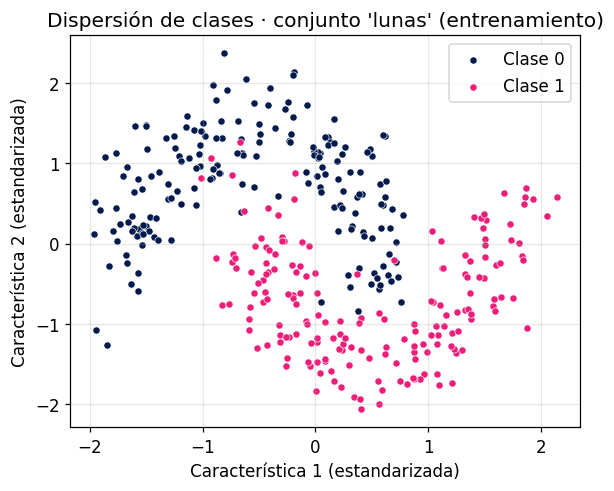

Balance de clases en entrenamiento → Clase 0: 180   Clase 1: 180


In [3]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Celda de soporte 3 · Exploración mínima (EDA)
# Qué hace · Dibuja la dispersión de las dos clases e informa el balance de clases.
# Por qué  · Si las clases están desbalanceadas o muy solapadas conviene saberlo antes de modelar: cambia qué métrica creer y qué arquitectura intentar.

fig, ax = plt.subplots(figsize=(5.5, 4.6))
for clase, color, etiqueta in [(0, USTA_NAVY, "Clase 0"), (1, USTA_ROSA, "Clase 1")]:
    mascara = y_train == clase
    ax.scatter(X_train[mascara, 0], X_train[mascara, 1],
               c=color, s=22, edgecolors="white", linewidths=0.4, label=etiqueta)
ax.set_xlabel("Característica 1 (estandarizada)")
ax.set_ylabel("Característica 2 (estandarizada)")
ax.set_title(f"Dispersión de clases · conjunto '{CONJUNTO}' (entrenamiento)")
ax.legend()
plt.tight_layout(); plt.show()

n0 = int((y_train == 0).sum()); n1 = int((y_train == 1).sum())
print(f"Balance de clases en entrenamiento → Clase 0: {miles(n0)}   Clase 1: {miles(n1)}")

## 3. `# TODO (estudiante)` · Arquitectura del MLP

> 📝 **Tarea del estudiante**
> Aquí inicia el trabajo evaluable. Se debe **definir la arquitectura** de un perceptrón multicapa para clasificación binaria, según exige la actividad.

**Requisitos mínimos:**

1. Importar PyTorch (`import torch`, `import torch.nn as nn`) y fijar también la semilla de torch (`torch.manual_seed(SEMILLA)`) para reproducibilidad.
2. Definir una **clase** que herede de `nn.Module` con **al menos dos capas ocultas**.
3. Usar una **no linealidad** en las capas ocultas (p. ej. `ReLU`) y una salida adecuada para clasificación **binaria** (p. ej. una unidad con `Sigmoid`, o una unidad lineal si luego se usa `BCEWithLogitsLoss`).
4. **Justificar** en una celda de texto la elección de las funciones de activación, apoyándose en la teoría de no linealidad del Módulo 1.
5. Prever un argumento de **`Dropout`** (probabilidad configurable, por defecto 0) que se usará en la Sección 6.

> 💡 *Pista de forma:* la entrada tiene **2 características** y la salida es **1** (probabilidad de la clase 1). La pérdida `BCELoss` espera las etiquetas con forma `(N, 1)`.

> ⚠️ La celda siguiente está **intencionalmente incompleta**: lanza `NotImplementedError` hasta que se reemplace el cuerpo por la implementación propia.

In [4]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# TODO (estudiante) · Definir la arquitectura del MLP
# Qué hace · Define un MLP de 2 capas ocultas (16 -> 8 neuronas) con ReLU y salida en logit.
# Por qué  · Dos capas ocultas permiten separar las clases no lineales de 'lunas'/'circulos';
#            la salida en logit (sin Sigmoid) se combina más adelante con BCEWithLogitsLoss,
#            que es numéricamente más estable que aplicar Sigmoid + BCELoss por separado.

import torch
import torch.nn as nn
torch.manual_seed(SEMILLA)

class MLP(nn.Module):
    """MLP para clasificación binaria: 2 -> [ocultas] -> 1.

    Arquitectura:
      - Capa oculta 1: n_entrada -> n_oculta,        ReLU, Dropout(p_dropout)
      - Capa oculta 2: n_oculta  -> n_oculta // 2,    ReLU, Dropout(p_dropout)
      - Capa de salida: n_oculta // 2 -> 1 (logit, SIN activación)
    """
    def __init__(self, n_entrada=2, n_oculta=16, p_dropout=0.0):
        super().__init__()
        self.red = nn.Sequential(
            nn.Linear(n_entrada, n_oculta),
            nn.ReLU(),
            nn.Dropout(p_dropout),
            nn.Linear(n_oculta, n_oculta // 2),
            nn.ReLU(),
            nn.Dropout(p_dropout),
            nn.Linear(n_oculta // 2, 1),   # logit: sin Sigmoid aquí
        )

    def forward(self, x):
        return self.red(x)

modelo_prueba = MLP(n_entrada=2, n_oculta=16, p_dropout=0.0)
n_params = sum(p.numel() for p in modelo_prueba.parameters())
print(modelo_prueba)
print(f"\nParámetros entrenables: {miles(n_params)}")

MLP(
  (red): Sequential(
    (0): Linear(in_features=2, out_features=16, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.0, inplace=False)
    (3): Linear(in_features=16, out_features=8, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.0, inplace=False)
    (6): Linear(in_features=8, out_features=1, bias=True)
  )
)

Parámetros entrenables: 193


### Justificación de las funciones de activación

- **ReLU en las capas ocultas.** Las dos clases de `make_moons` / `make_circles` no son separables por una frontera lineal; se necesita que la red componga varias fronteras lineales para aproximar una curva. ReLU introduce esa no linealidad sin saturar para valores positivos (a diferencia de `Sigmoid`/`Tanh`), lo que evita el desvanecimiento del gradiente al apilar capas y acelera la convergencia.
- **Salida en logit (sin activación final).** La última capa entrega un valor real sin acotar. Aplicar `Sigmoid` dentro del modelo y luego `BCELoss` es matemáticamente equivalente a usar `BCEWithLogitsLoss` sobre el logit, pero esta segunda opción es **numéricamente más estable**: combina el logaritmo y la sigmoide en una sola operación, evitando log(0) cuando la probabilidad se acerca a 0 o 1.
- **Dropout previsto (`p_dropout`).** Se deja como argumento configurable (por defecto `0.0`, es decir, desactivado) porque en esta sección el objetivo es solo definir una arquitectura sana; el uso real de Dropout como regularizador se reserva para el experimento de sobreajuste de la Sección 6.

## 4. `# TODO (estudiante)` · Pérdida, optimizador y bucle de entrenamiento

> 📝 **Tarea del estudiante**
> Con el modelo ya definido, se debe **configurar el entrenamiento** y escribir el **bucle explícito**, según exige la actividad: por **50 épocas**, registrando la pérdida de entrenamiento y de validación en cada época.

**Los cinco pasos que cada época debe ejecutar, en orden:**

1. **forward** — calcular las predicciones del modelo sobre el conjunto de entrenamiento.
2. **pérdida** — comparar las predicciones con la verdad (p. ej. `BCELoss`).
3. **`zero_grad`** — limpiar los gradientes acumulados de la época anterior.
4. **`backward`** — retropropagar el error (calcular los gradientes).
5. **`step`** — el optimizador actualiza los pesos.

**Indicaciones:**

- Convertir `X_train, y_train, X_val, y_val` a **tensores** de PyTorch (`float32`); las etiquetas con forma `(N, 1)`.
- Elegir una **función de pérdida** para clasificación binaria y un **optimizador** (SGD o Adam) con una **tasa de aprendizaje** inicial.
- Devolver el historial de pérdidas (`train` y `val`) para graficarlo con los helpers de la Sección 5.

> ⚠️ La celda siguiente está **intencionalmente incompleta**. Debe completarse el cuerpo de `entrenar(...)` y la conversión a tensores antes de ejecutarla.

In [5]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# TODO (estudiante) · Configurar pérdida/optimizador y escribir el bucle de entrenamiento
# Qué hace · Convierte los arreglos de numpy a tensores, entrena el MLP por 50 épocas con los
#            cinco pasos explícitos (forward, pérdida, zero_grad, backward, step) y registra el
#            historial de pérdidas de entrenamiento y validación en cada época.
# Por qué  · Un bucle explícito (en vez de un .fit() de alto nivel) hace visible el mecanismo
#            interno del descenso de gradiente, que es justamente lo que evalúa esta actividad.

# --- 1) Conversión a tensores de PyTorch -------------------------------------
def a_tensor(Xa, ya):
    return (torch.tensor(Xa, dtype=torch.float32),
            torch.tensor(ya, dtype=torch.float32).view(-1, 1))

X_train_t, y_train_t = a_tensor(X_train, y_train)
X_val_t,   y_val_t   = a_tensor(X_val,   y_val)
X_test_t,  y_test_t  = a_tensor(X_test,  y_test)

# --- 2) Bucle de entrenamiento explícito -------------------------------------
def entrenar(modelo, X_tr, y_tr, X_va, y_va, epocas=50, lr=0.05):
    """Entrena el MLP por 'epocas' épocas y devuelve el historial de pérdidas.

    En cada época, exactamente en este orden:
        (1) forward    -> predicciones sobre el conjunto de entrenamiento
        (2) pérdida    -> BCEWithLogitsLoss entre predicción y etiqueta real
        (3) zero_grad  -> limpiar gradientes acumulados de la época anterior
        (4) backward   -> retropropagar el error (calcular gradientes)
        (5) step       -> el optimizador actualiza los pesos
    La pérdida de validación se calcula aparte, sin gradientes (modelo.eval()).
    """
    criterio = nn.BCEWithLogitsLoss()
    optimizador = torch.optim.Adam(modelo.parameters(), lr=lr)
    historial = {"train": [], "val": []}

    for epoca in range(epocas):
        modelo.train()
        y_pred_tr = modelo(X_tr)                      # (1) forward
        loss_tr = criterio(y_pred_tr, y_tr)            # (2) pérdida
        optimizador.zero_grad()                        # (3) zero_grad
        loss_tr.backward()                              # (4) backward
        optimizador.step()                              # (5) step
        historial["train"].append(loss_tr.item())

        modelo.eval()
        with torch.no_grad():
            loss_va = criterio(modelo(X_va), y_va)
            historial["val"].append(loss_va.item())

    return historial

# --- 3) Instanciar el modelo y entrenar --------------------------------------
modelo = MLP(n_entrada=2, n_oculta=16, p_dropout=0.0)
historial = entrenar(modelo, X_train_t, y_train_t, X_val_t, y_val_t, epocas=50, lr=0.05)

print(f"Pérdida final · entrenamiento: {historial['train'][-1]:.4f}  ·  validación: {historial['val'][-1]:.4f}")

Pérdida final · entrenamiento: 0.1019  ·  validación: 0.1254


## 5. Funciones de diagnóstico provistas

Estas dos funciones **ya están implementadas** y son las que el estudiante **invoca** para diagnosticar el entrenamiento. No dependen de PyTorch: reciben listas o arreglos de `numpy`, de modo que funcionan con el historial y las predicciones que produzca cualquier implementación del modelo.

- `plot_curvas_perdida(train_losses, val_losses)` — superpone las curvas de pérdida de entrenamiento y validación; la **brecha** entre ambas es la firma del sobreajuste.
- `plot_matriz_confusion(y_true, y_pred)` — dibuja la matriz de confusión, que separa *falsos positivos* (FP) de *falsos negativos* (FN), base de la **auditoría ética** del proyecto.


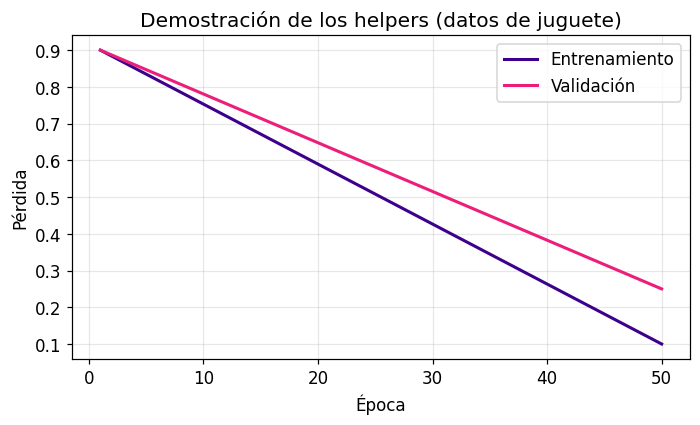

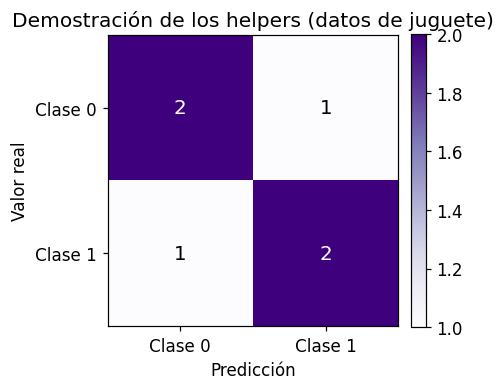

Funciones de diagnóstico listas: plot_curvas_perdida(...) y plot_matriz_confusion(...).


In [6]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Celda de soporte 4 · Funciones de diagnóstico (FUNCIONALES — listas para usar)
# Qué hace · Define plot_curvas_perdida y plot_matriz_confusion con matplotlib/sklearn.
# Por qué  · El estudiante solo las invoca; no dependen de torch, así que funcionan con numpy.

def plot_curvas_perdida(train_losses, val_losses, titulo="Curva de pérdida"):
    """Grafica la pérdida de entrenamiento frente a la de validación por época.

    Parámetros
    ----------
    train_losses, val_losses : list | np.ndarray
        Pérdida registrada en cada época para entrenamiento y validación.
    """
    train_losses = np.asarray(train_losses, dtype=float)
    val_losses = np.asarray(val_losses, dtype=float)
    epocas = np.arange(1, len(train_losses) + 1)
    fig, ax = plt.subplots(figsize=(6.5, 4))
    ax.plot(epocas, train_losses, color=USTA_MORADO, lw=2, label="Entrenamiento")
    ax.plot(epocas, val_losses, color=USTA_ROSA, lw=2, label="Validación")
    ax.set_xlabel("Época"); ax.set_ylabel("Pérdida")
    ax.set_title(titulo); ax.legend()
    plt.tight_layout(); plt.show()


def plot_matriz_confusion(y_true, y_pred, etiquetas=("Clase 0", "Clase 1"),
                          titulo="Matriz de confusión"):
    """Dibuja la matriz de confusión (2x2) con sus conteos anotados.

    Parámetros
    ----------
    y_true, y_pred : array-like de 0/1
        Etiquetas verdaderas y predichas (mismo largo).
    """
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    fig, ax = plt.subplots(figsize=(4.4, 4))
    im = ax.imshow(cm, cmap="Purples")
    ax.set_xticks([0, 1], labels=etiquetas)
    ax.set_yticks([0, 1], labels=etiquetas)
    ax.set_xlabel("Predicción"); ax.set_ylabel("Valor real")
    ax.set_title(titulo)
    umbral = cm.max() / 2 if cm.max() > 0 else 0.5
    for i in range(2):
        for j in range(2):
            ax.text(j, i, miles(int(cm[i, j])), ha="center", va="center",
                    color="white" if cm[i, j] > umbral else "black", fontsize=13)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.grid(False)
    plt.tight_layout(); plt.show()


# --- Comprobación rápida con datos de juguete (verifica que los helpers funcionan) ---
_demo_train = np.linspace(0.9, 0.1, 50)
_demo_val = _demo_train + np.linspace(0.0, 0.15, 50)
plot_curvas_perdida(_demo_train, _demo_val, titulo="Demostración de los helpers (datos de juguete)")
plot_matriz_confusion([0, 0, 1, 1, 0, 1], [0, 1, 1, 1, 0, 0],
                      titulo="Demostración de los helpers (datos de juguete)")
print("Funciones de diagnóstico listas: plot_curvas_perdida(...) y plot_matriz_confusion(...).")

### Diagnóstico de la línea base (antes del experimento de sobreajuste)

Se aplican las dos funciones anteriores al modelo entrenado en la Sección 4, para confirmar que la línea base generaliza razonablemente **antes** de forzar el sobreajuste en la Sección 6.

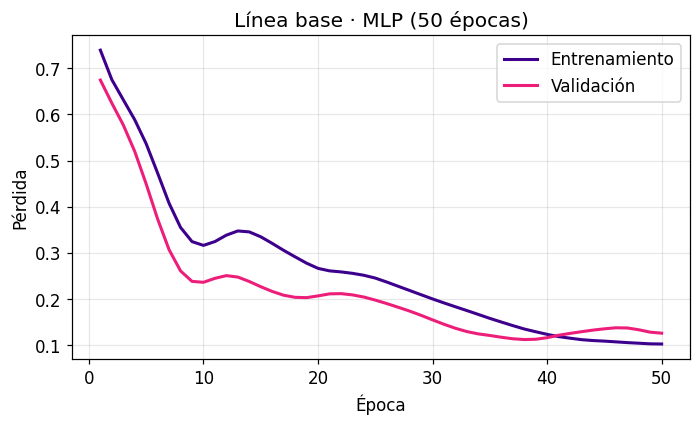

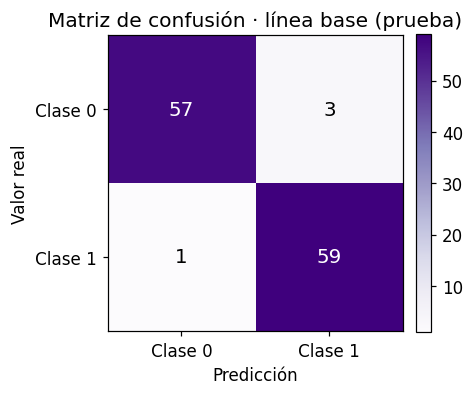

In [7]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Aplicación · Diagnóstico de la línea base entrenada en la Sección 4
# Qué hace · Grafica las curvas de pérdida del entrenamiento y evalúa la línea base en PRUEBA.
# Por qué  · Antes de forzar el sobreajuste (Sección 6) conviene confirmar que el modelo "sano" generaliza.

plot_curvas_perdida(historial["train"], historial["val"], titulo="Línea base · MLP (50 épocas)")

modelo.eval()
with torch.no_grad():
    probs_base = torch.sigmoid(modelo(X_test_t)).numpy().ravel()
y_pred_base = (probs_base >= 0.5).astype(int)

plot_matriz_confusion(y_test, y_pred_base, titulo="Matriz de confusión · línea base (prueba)")

## 6. `# TODO (estudiante)` · Inducir y corregir el sobreajuste con *Dropout*

> 📝 **Tarea del estudiante**
> Este es el **desafío** de la actividad. Se debe **inducir el sobreajuste a propósito** y luego **corregirlo**, documentando el cambio con las gráficas.

**Pasos sugeridos:**

1. **Inducir el sobreajuste:** entrenar una red **más grande** (más neuronas y/o más épocas) sobre **pocos datos ruidosos**. Graficar las curvas con `plot_curvas_perdida(...)` y observar cómo la pérdida de validación **se separa** de la de entrenamiento.
2. **Corregirlo:** volver a entrenar una red equivalente añadiendo **`Dropout`** (usando el argumento `p_dropout` previsto en la Sección 3) o ajustando la tasa de aprendizaje. Volver a graficar y **comparar la brecha** *train / val* antes y después.
3. **Evaluar en la prueba:** generar las predicciones sobre el conjunto de **prueba** (`X_test`) y dibujar la matriz de confusión con `plot_matriz_confusion(...)`.
4. **Reflexión ética:** comentar el coste asimétrico de los **falsos positivos** frente a los **falsos negativos** en el contexto del problema elegido (conecta con la auditoría ética del informe).

> ⚠️ La celda siguiente está **vacía a propósito**. El estudiante escribe aquí el experimento de sobreajuste, reutilizando `MLP`, `entrenar(...)` y los helpers de diagnóstico.

Subconjunto reducido para forzar el sobreajuste: 40 muestras (de 360 disponibles en entrenamiento).


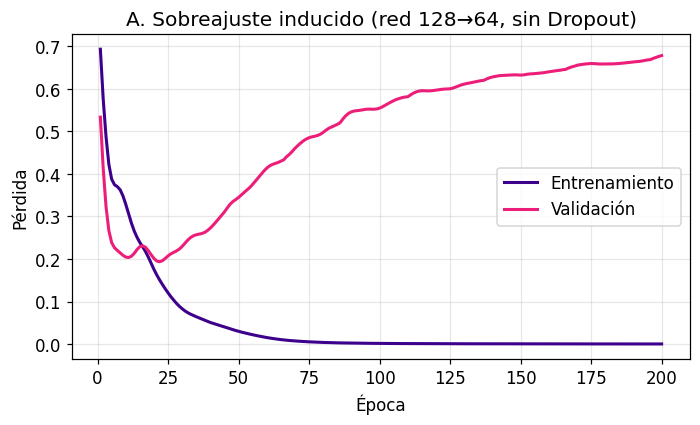

[Sobreajuste] pérdida final -> train: 0.0003  val: 0.6784  (brecha: 0.6781)


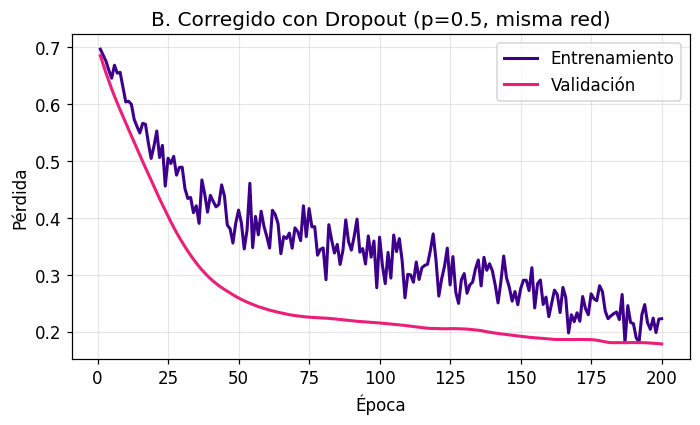

[Con Dropout] pérdida final -> train: 0.2229  val: 0.1785  (brecha: -0.0444)


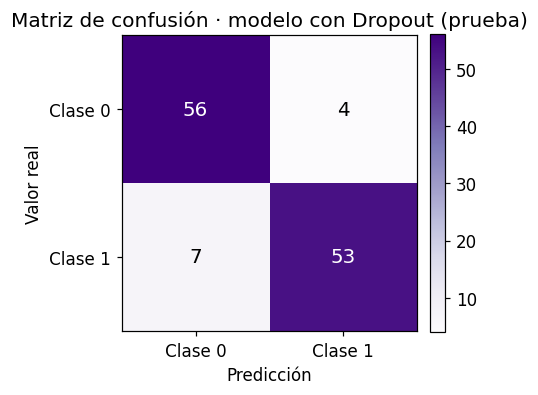

In [8]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# TODO (estudiante) · Inducir el sobreajuste y corregirlo con Dropout
# Qué hace · (1) Reduce el conjunto de entrenamiento a una muestra pequeña y entrena una red
#            grande sin regularizar -> se abre la brecha train/val. (2) Repite el experimento
#            con la misma red pero con Dropout activado -> la brecha se cierra. (3) Evalúa el
#            modelo regularizado sobre el conjunto de PRUEBA con la matriz de confusión.
# Por qué  · Sobreajuste = memorizar en vez de generalizar. Verlo aparecer y luego corregirlo
#            con Dropout es la evidencia que pide la rúbrica para el criterio de regularización.

# --- 1) Reducir el conjunto de entrenamiento (pocos datos -> más fácil memorizar) ---
N_POCOS = 40
rng = np.random.RandomState(SEMILLA)
idx_pocos = rng.choice(len(X_train_t), size=N_POCOS, replace=False)
X_poco_t, y_poco_t = X_train_t[idx_pocos], y_train_t[idx_pocos]
print(f"Subconjunto reducido para forzar el sobreajuste: {miles(N_POCOS)} muestras "
      f"(de {miles(len(X_train_t))} disponibles en entrenamiento).")

# --- 2) EXPERIMENTO A · Sobreajuste inducido (red grande, sin Dropout, muchas épocas) ---
torch.manual_seed(SEMILLA)
modelo_sobre = MLP(n_entrada=2, n_oculta=128, p_dropout=0.0)
hist_sobre = entrenar(modelo_sobre, X_poco_t, y_poco_t, X_val_t, y_val_t, epocas=200, lr=0.01)

plot_curvas_perdida(hist_sobre["train"], hist_sobre["val"],
                     titulo="A. Sobreajuste inducido (red 128→64, sin Dropout)")
print(f"[Sobreajuste] pérdida final -> train: {hist_sobre['train'][-1]:.4f}  "
      f"val: {hist_sobre['val'][-1]:.4f}  (brecha: {hist_sobre['val'][-1]-hist_sobre['train'][-1]:.4f})")

# --- 3) EXPERIMENTO B · Corrección con Dropout (misma red, p_dropout=0.5) ---
torch.manual_seed(SEMILLA)
modelo_reg = MLP(n_entrada=2, n_oculta=128, p_dropout=0.5)
hist_reg = entrenar(modelo_reg, X_poco_t, y_poco_t, X_val_t, y_val_t, epocas=200, lr=0.001)

plot_curvas_perdida(hist_reg["train"], hist_reg["val"],
                     titulo="B. Corregido con Dropout (p=0.5, misma red)")
print(f"[Con Dropout] pérdida final -> train: {hist_reg['train'][-1]:.4f}  "
      f"val: {hist_reg['val'][-1]:.4f}  (brecha: {hist_reg['val'][-1]-hist_reg['train'][-1]:.4f})")

# --- 4) Evaluación en el conjunto de PRUEBA (modelo ya corregido) -------------
modelo_reg.eval()
with torch.no_grad():
    probs_test = torch.sigmoid(modelo_reg(X_test_t)).numpy().ravel()
y_pred_test = (probs_test >= 0.5).astype(int)

plot_matriz_confusion(y_test, y_pred_test,
                       titulo="Matriz de confusión · modelo con Dropout (prueba)")

### Reflexión ética · falsos positivos vs. falsos negativos

- **Falso positivo (predecir riesgo cuando no lo hay).** En el proyecto real (tamizaje de un evento de riesgo en salud), significa citar a una persona sana a una revisión adicional: el costo es operativo (tiempo del especialista, incomodidad de la persona) pero reversible.
- **Falso negativo (predecir "sin riesgo" cuando sí lo hay).** Significa dejar sin seguimiento a alguien que sí lo necesita: el costo es clínico y, según el evento de riesgo del proyecto elegido, puede ser irreversible.
- **Consecuencia para el umbral de decisión.** Cuando el costo de un falso negativo es claramente mayor que el de un falso positivo, conviene desplazar el umbral de clasificación por debajo de 0.5 (p. ej. a 0.3) para priorizar el *Recall* de la clase de riesgo, aun a costa de generar más falsos positivos. La elección final del umbral es una decisión de negocio/clínica, no solo técnica, y debe discutirse con el cliente según su capacidad operativa.

## 7. Cierre · Lista de entregables

Una vez completadas las secciones 3, 4 y 6 sobre los **datos propios** del proyecto (no sobre estos datos sintéticos), la Fase 1 se entrega con cuatro piezas:

- [ ] **Notebook** (`.ipynb`) comentado: carga y EDA de los datos reales, arquitectura del MLP justificada, bucle de entrenamiento explícito por 50 épocas, curvas de pérdida y experimento de sobreajuste/Dropout documentado.
- [ ] **Informe técnico-ético** (PDF, máx. 4 páginas): análisis de las gráficas y la reflexión ética sobre el coste de los falsos positivos para el cliente.
- [ ] **Propuesta de Datos** aprobada por el docente (el *gate* del Paso 0 de la actividad), incluida en el `.zip`.
- [ ] **Bitácora de IA**: registro de las interacciones relevantes con la IA generativa —qué se pidió, qué devolvió, qué se **aceptó / modificó / rechazó** y **por qué**—, incluyendo al menos **un caso en que la IA falló** y cómo se corrigió.

> ⚠️ **Este andamiaje no se entrega tal cual**
> Este cuaderno es punto de partida y trabaja con **datos sintéticos**. La entrega evaluable debe aplicarse a los **datos reales** del problema elegido y aprobado, e incluir el informe y la bitácora. Reutilizar este scaffold sin adaptarlo al propio problema **no satisface** la actividad.

### 🔗 Relacionado
- Página principal de la bóveda y mapa del Segundo Cerebro.
- Syllabus del Curso y Ruta de Aprendizaje.
- Documento maestro: **Proyecto Integrador Centinela** (especificación longitudinal de las tres fases).
- **Fase 1 (evaluable):** Actividad · **Proyecto Centinela · Fase 1** (Línea Base con MLP).
- **Material teórico:** Módulo 1 — Capítulos 2 (MLP), 3 (optimización) y 5 (regularización y ética).
- **Uso de IA:** plantilla de la Bitácora de IA para registrar el proceso de la fase.